# Post 04: How Do Thermostats Change Sampling and Dynamics?

This notebook is the presentation layer for the fourth tutorial. The reusable BAOAB Langevin thermostat diagnostics and figure logic live in `src/kups_md_tutorials/`.

The goal is to separate two facts that are easy to conflate: a thermostat may target the right canonical distribution while still changing dynamical memory and time-correlation functions.

In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.config import load_thermostat_spec
from kups_md_tutorials.figures import generate_post04_figures
from kups_md_tutorials.thermostats import (
    load_thermostat_summary,
    simulate_baoab_langevin,
)

## Configuration

The smoke and full profiles use a one-dimensional harmonic oscillator with BAOAB Langevin dynamics. The full profile compares weak, moderate, and strong thermostat coupling at the same target temperature.

In [3]:
smoke_spec = load_thermostat_spec("04", "smoke")
full_spec = load_thermostat_spec("04", "full")

for label in ["smoke", "full"]:
    config_path = Path(f"configs/post-04/{label}.json")
    print(f"--- {label} ---")
    print(json.dumps(json.loads(config_path.read_text()), indent=2))

--- smoke ---
{
  "post": "04",
  "profile": "smoke",
  "title": "How Do Thermostats Change Sampling and Dynamics?",
  "system": {
    "kind": "harmonic_oscillator",
    "mass": 1.0,
    "omega": 1.0
  },
  "thermostat_experiment": {
    "temperature": 1.0,
    "time_step": 0.02,
    "num_steps": 4000,
    "warmup_steps": 500,
    "sample_every": 4,
    "seed": 2026071404,
    "thermostats": [
      {
        "name": "weak_langevin",
        "method": "baoab_langevin",
        "gamma": 0.1
      },
      {
        "name": "strong_langevin",
        "method": "baoab_langevin",
        "gamma": 5.0
      }
    ]
  }
}
--- full ---
{
  "post": "04",
  "profile": "full",
  "title": "How Do Thermostats Change Sampling and Dynamics?",
  "system": {
    "kind": "harmonic_oscillator",
    "mass": 1.0,
    "omega": 1.0
  },
  "thermostat_experiment": {
    "temperature": 1.0,
    "time_step": 0.02,
    "num_steps": 40000,
    "warmup_steps": 5000,
    "sample_every": 10,
    "seed": 2026071404,

## One Thermostat Step Is Not Just A Temperature Fix

BAOAB alternates deterministic force/drift updates with an Ornstein-Uhlenbeck velocity refresh. The refresh controls sampling, but its coupling strength also changes dynamical memory.

In [4]:
case = full_spec.experiment.thermostats[1]
times, positions, velocities = simulate_baoab_langevin(
    mass=full_spec.system.mass,
    omega=full_spec.system.omega,
    temperature=full_spec.experiment.temperature,
    time_step=full_spec.experiment.time_step,
    num_steps=200,
    warmup_steps=20,
    sample_every=10,
    gamma=case.gamma,
    seed=full_spec.experiment.seed,
)
list(zip(times[:5], positions[:5], velocities[:5]))

[(np.float64(0.4),
  np.float64(-0.5680532523959834),
  np.float64(0.3237262578951452)),
 (np.float64(0.6),
  np.float64(-0.552083954234525),
  np.float64(0.4187870665173119)),
 (np.float64(0.8),
  np.float64(-0.48962306133997),
  np.float64(0.6333239976627559)),
 (np.float64(1.0),
  np.float64(-0.21767442672654372),
  np.float64(1.4229703193858734)),
 (np.float64(1.2),
  np.float64(0.11614282385699246),
  np.float64(1.7004717412031753))]

## Committed Outputs

The repository commits smoke and full summaries plus downsampled samples. The summary compares observed configurational and kinetic moments to the canonical targets and records autocorrelation diagnostics.

In [5]:
result_dirs = {
    "smoke": Path("results/post-04/smoke"),
    "full": Path("results/post-04/full"),
}

for label, result_dir in result_dirs.items():
    print(f"--- {label} ---")
    for path in sorted(result_dir.iterdir()):
        print(f"{path}: {path.stat().st_size} bytes")

full_summary = load_thermostat_summary(result_dirs["full"] / "thermostat_summary.json")
full_summary

--- smoke ---
results/post-04/smoke/manifest.json: 1194 bytes
results/post-04/smoke/thermostat_samples.csv: 29625 bytes
results/post-04/smoke/thermostat_summary.json: 2154 bytes
--- full ---
results/post-04/full/manifest.json: 1316 bytes
results/post-04/full/thermostat_samples.csv: 67253 bytes
results/post-04/full/thermostat_summary.json: 3100 bytes


ThermostatExperimentSummary(post='04', profile='full', mass=1.0, omega=1.0, temperature=1.0, time_step=0.02, sample_every=10, seed=2026071404, config_sha256='76d18d222650176601cd88e8633a1329565a25649635afbd44a2a36b95dde6a6', runs=[ThermostatRunSummary(thermostat='weak_langevin', method='baoab_langevin', gamma=0.1, samples=3500, position_mean=-0.006742745091097653, position_variance=0.9209247661562039, velocity_mean=-0.0022900861106303623, velocity_variance=0.9451332619305071, kinetic_mean=0.4724342341750319, kinetic_variance=0.3704328472249247, expected_position_variance=1.0, expected_velocity_variance=1.0, expected_kinetic_mean=0.5, position_variance_relative_error=-0.07907523384379611, velocity_variance_relative_error=-0.05486673806949294, kinetic_mean_relative_error=-0.05513153164993623, position_lag1_autocorrelation=0.9794995830249427, velocity_lag1_autocorrelation=0.9584973525375968, position_integrated_autocorrelation_time=10.07042143977572, position_effective_samples=347.5524853

## Diagnostic Figure

The figure uses the full profile. It shows that the thermostat cases sample near the same canonical targets, while strong coupling substantially increases the position autocorrelation time.

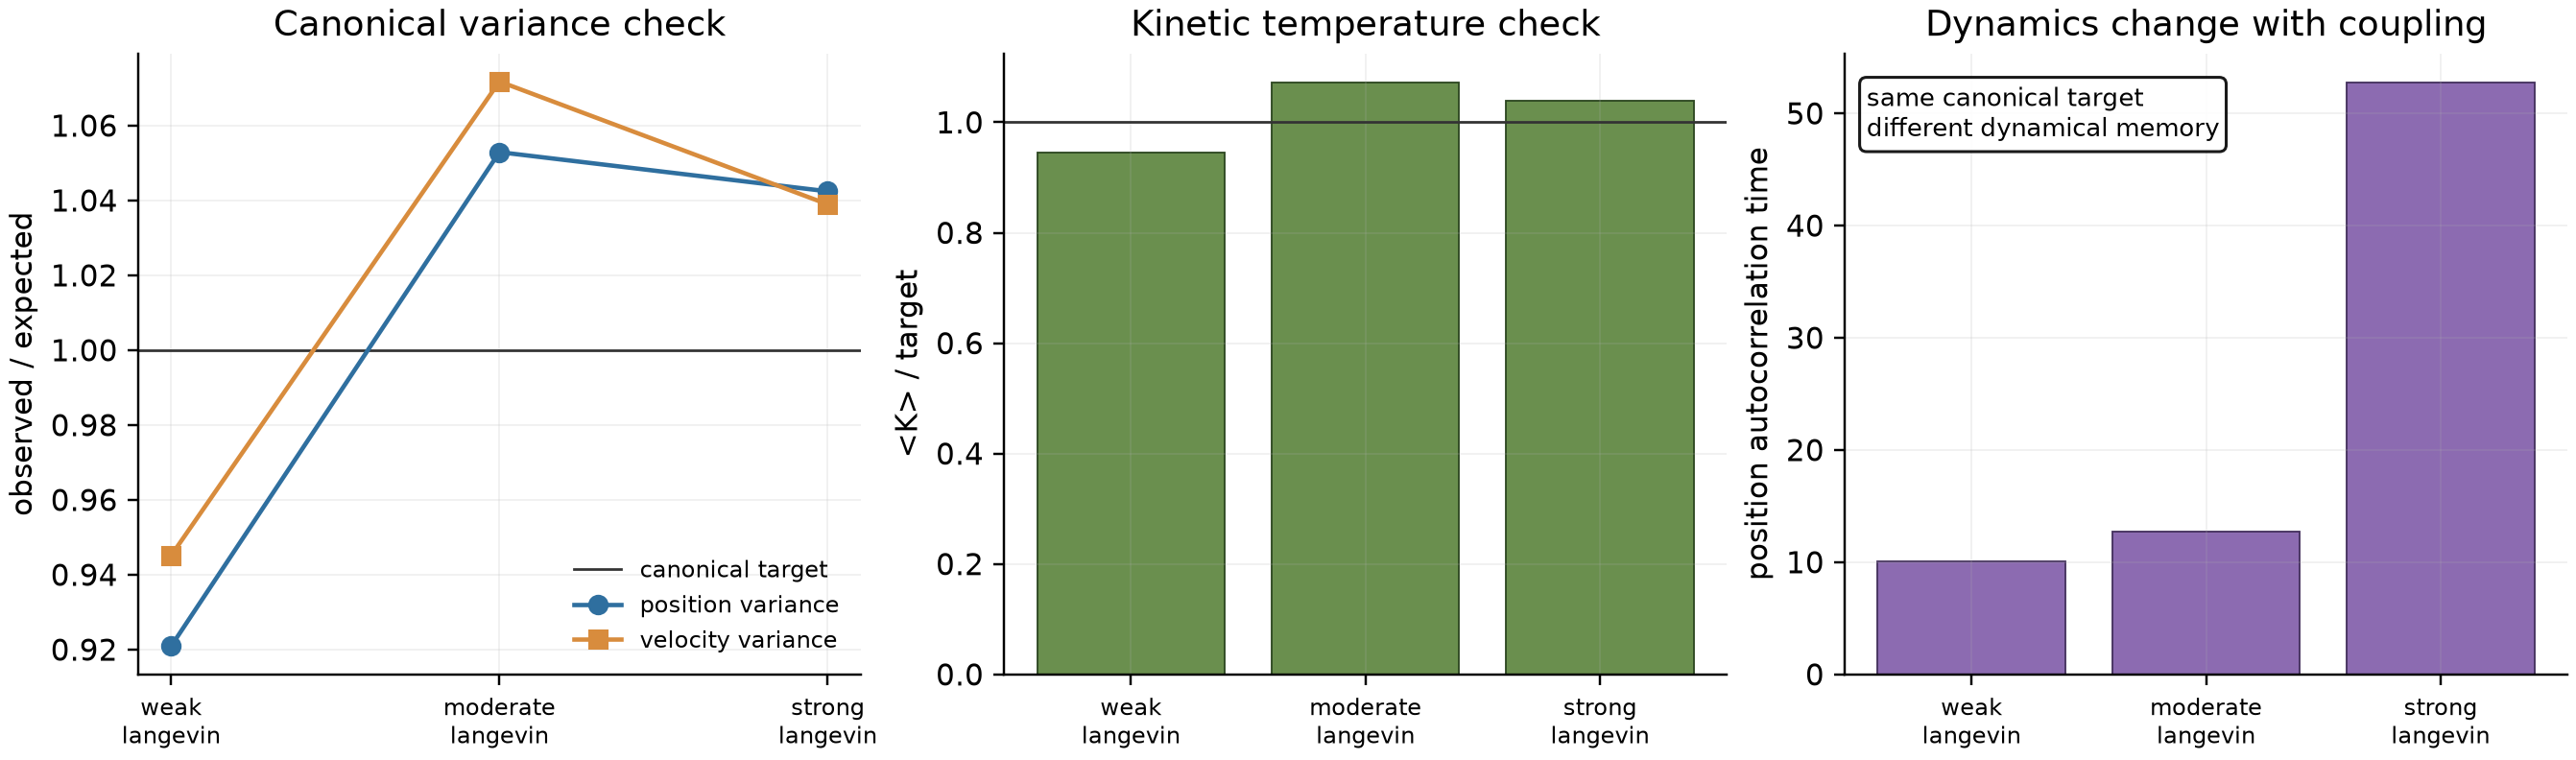

In [6]:
generate_post04_figures(
    result_dir=result_dirs["full"],
    figure_dir=Path("figures/post-04"),
    snapshot_dir=Path("snapshots/post-04"),
    name="thermostat_diagnostics_full",
)
display(Image(filename="figures/post-04/thermostat_diagnostics_full.png"))

## Takeaways

- A thermostat should be checked against canonical configurational and kinetic targets.
- Matching the temperature is not the same as preserving dynamics.
- Strong Langevin coupling can increase autocorrelation even when moments look acceptable.
- Later argon workflows should switch to NVE production when dynamical observables matter.